In [7]:
import sys
sys.path.insert(0, '../lib')

import glob
import os
import pickle
import datetime
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import datasets
import numpy as np
import pandas as pd
import wandb
import scipy
import sklearn.metrics
import torch
import torch.distributions as td
import scanpy as sc

import common_data

In [2]:
%config InlineBackend.figure_format = "retina"

In [3]:
pd.options.display.max_columns = 300
pd.options.display.max_rows = 350
pd.options.display.max_colwidth = 10000

In [4]:
mpl.rc_file_defaults()

In [5]:
with open('02_model_perf.pkl', 'rb') as f:
    model_perf = pickle.load(f)

with open('02_model_df.pkl', 'rb') as f:
    df = pickle.load(f)

In [6]:
def compute_metrics(y_pred_probs, y_pred, y_true):
    auprc = sklearn.metrics.average_precision_score(y_true, y_pred_probs)
    f1_binary = sklearn.metrics.f1_score(y_true, y_pred, average='binary')
    roc_auc = sklearn.metrics.roc_auc_score(y_true, y_pred_probs)
    accuracy = sklearn.metrics.accuracy_score(y_true, y_pred)
    recall = sklearn.metrics.recall_score(y_true, y_pred)
    precision = sklearn.metrics.precision_score(y_true, y_pred)

    return {
        'accuracy': accuracy,
        'f1_binary': f1_binary,
        'AUROC': roc_auc,
        'AUPRC': auprc,
        'recall': recall,
        'precision': precision,
    }

In [8]:
adata = sc.read_h5ad(common_data.SC_NORM)

# 1. Variation in performance due to technical covariates

We want to see if there is a correlation or in general different performance for cells along these metadata:
- n_genes_by_counts
- total_counts
- pct_counts_mito
- pct_counts_ribo

First, across all cells

In [11]:
COVARIATES = [
    'n_genes_by_counts',
    'total_counts',
    'pct_counts_mito',
    'pct_counts_ribo'
]

In [17]:
%%time

corr_data = []
for model_path, model_df in model_perf.items():
    model_df = model_df.copy()
    model_df['correct_pred'] = (model_df.true_label == model_df.pred_label).astype(int)
    for covariate in COVARIATES:
        model_df[covariate] = adata.obs.loc[model_df.obs_names.values, covariate].values
        corr = scipy.stats.pearsonr(model_df[covariate], model_df.correct_pred)
        corr_data.append(dict(
            model_path=model_path,
            covariate=covariate,
            corr_coef=corr.statistic,
            pval=corr.pvalue
        ))

CPU times: user 43.9 s, sys: 62.9 ms, total: 43.9 s
Wall time: 44 s


In [18]:
corr_results = pd.DataFrame(corr_data)

Text(0.5, 1.0, 'Distribution of correlation coefficients with correctness of predictions')

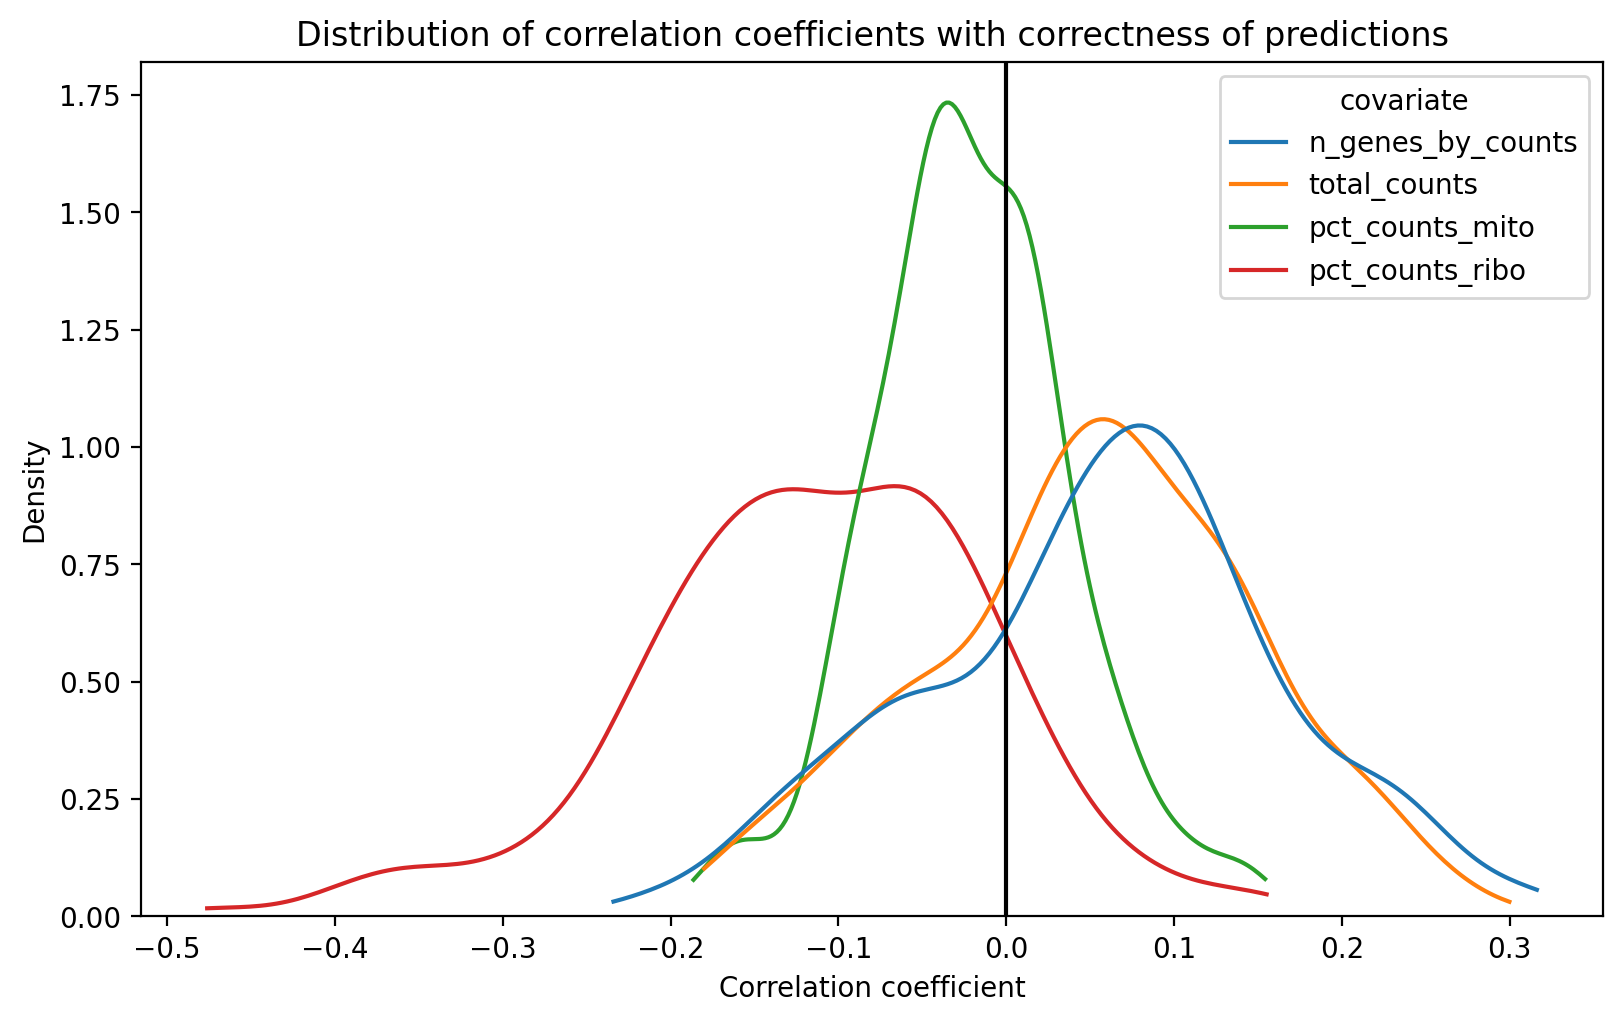

In [30]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sns.kdeplot(
    data=corr_results,
    x='corr_coef',
    hue='covariate',
    cut=0
)
ax.axvline(0, c='k')
ax.set_xlabel('Correlation coefficient')
ax.set_title('Distribution of correlation coefficients with correctness of predictions')

In [31]:
%%time

corr_data = []
for model_path, model_df in model_perf.items():
    model_df = model_df.copy()
    for covariate in COVARIATES:
        model_df[covariate] = adata.obs.loc[model_df.obs_names.values, covariate].values
        corr = scipy.stats.pearsonr(model_df[covariate], model_df.entropy)
        corr_data.append(dict(
            model_path=model_path,
            covariate=covariate,
            corr_coef=corr.statistic,
            pval=corr.pvalue
        ))

CPU times: user 39.8 s, sys: 543 ms, total: 40.4 s
Wall time: 40.5 s


In [32]:
corr_results = pd.DataFrame(corr_data)

Text(0.5, 1.0, 'Distribution of correlation coefficients with entropy of predictions')

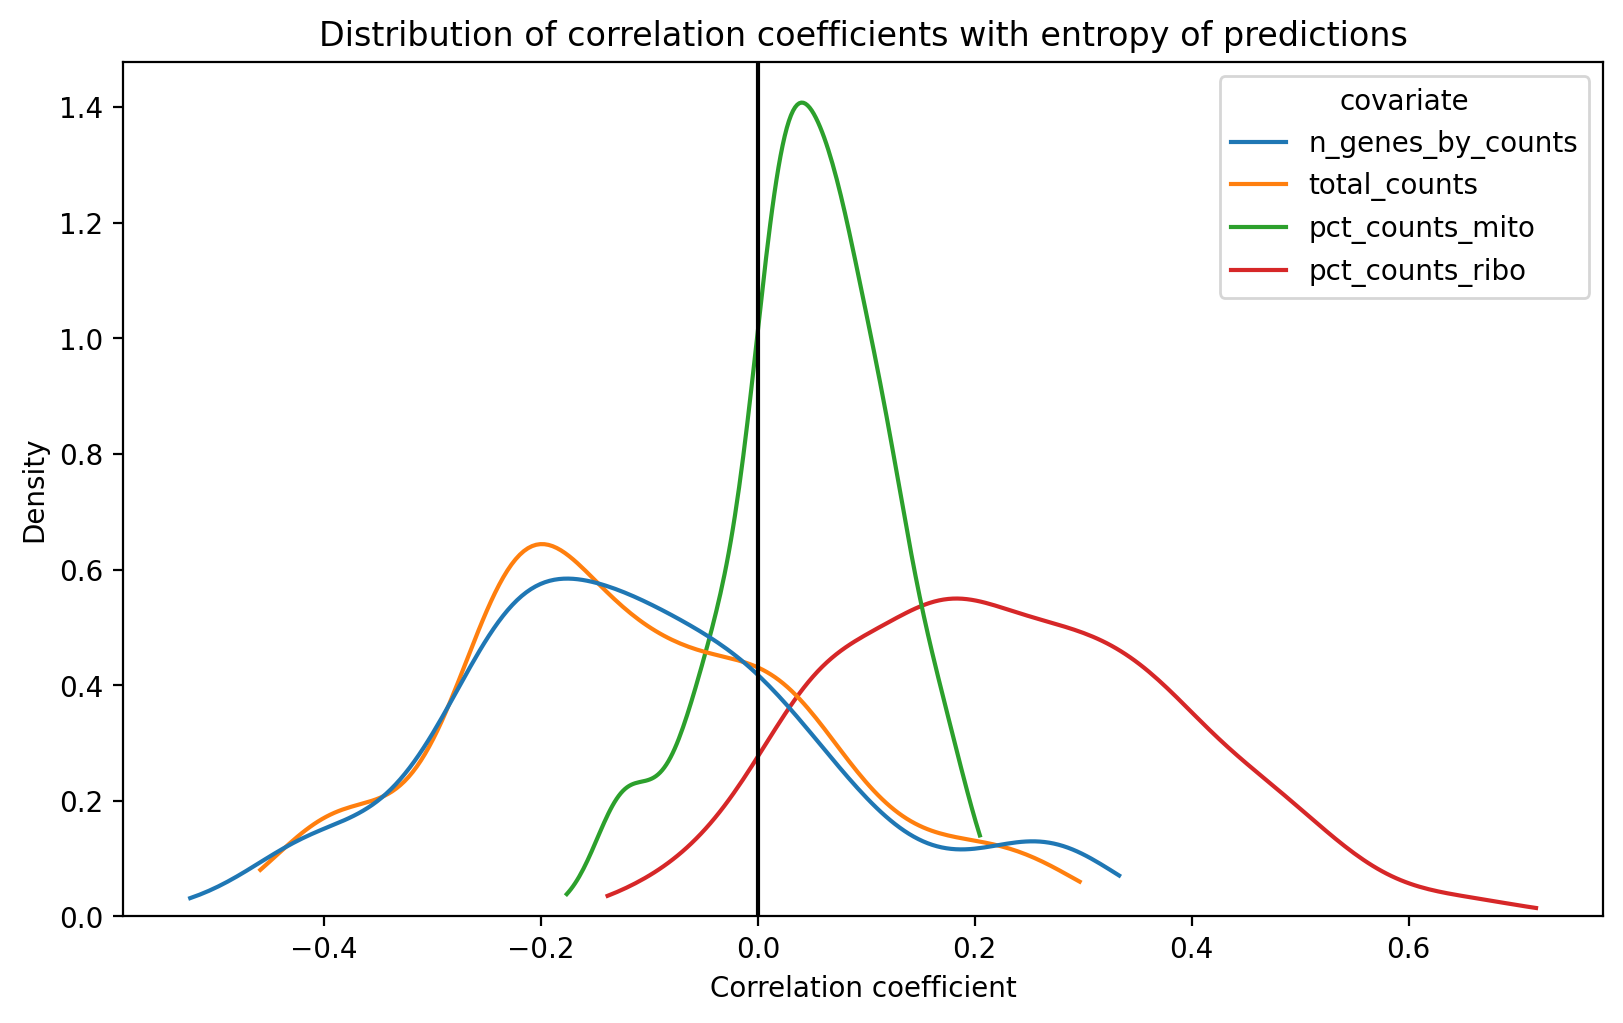

In [33]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sns.kdeplot(
    data=corr_results,
    x='corr_coef',
    hue='covariate',
    cut=0
)
ax.axvline(0, c='k')
ax.set_xlabel('Correlation coefficient')
ax.set_title('Distribution of correlation coefficients with entropy of predictions')

In [35]:
scipy.stats.pearsonr(adata.obs.pct_counts_ribo, adata.obs.total_counts)

PearsonRResult(statistic=-0.1582319283785938, pvalue=0.0)

In [36]:
scipy.stats.pearsonr(adata.obs.n_genes_by_counts, adata.obs.total_counts)

PearsonRResult(statistic=0.9292067378078098, pvalue=0.0)

**Conclusions**:

- n_genes and total_counts are very correlated
- both are correlated mildly with correctness of predictions and anticorrelated midly with the entropy
- pct_counts_ribo behaves the reverse
- pct_counts_ribo is not anticorrelated with total_counts
- pct_counts_mito is neutral
- both correlation distributions display large variation
- because of that we want to analyze within cell types

# 2. Variation in performance with technical covariates by cell type

In [37]:
all_cell_types = set()
for model_df in model_perf.values():
    all_cell_types |= set(model_df.cell_types.unique())

In [42]:
%%time

corr_data = []
for model_path, model_df in model_perf.items():
    model_df = model_df.copy()
    model_df['correct_pred'] = (model_df.true_label == model_df.pred_label).astype(int)
    for covariate in COVARIATES:
        model_df[covariate] = adata.obs.loc[model_df.obs_names.values, covariate].values

    for cell_type in all_cell_types:
        idx = model_df.cell_types.eq(cell_type)
        if idx.sum() < 2:
            continue
        for covariate in COVARIATES:
            corr = scipy.stats.pearsonr(model_df[covariate][idx], model_df.correct_pred[idx])
            corr_data.append(dict(
                model_path=model_path,
                cell_type=cell_type,
                covariate=covariate,
                corr_coef=corr.statistic,
                pval=corr.pvalue
            ))

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scip

CPU times: user 1min 45s, sys: 946 ms, total: 1min 46s
Wall time: 1min 47s


In [43]:
corr_results = pd.DataFrame(corr_data)

In [44]:
corr_results['model'] = corr_results.model_path.str.split('/').str[-1]
corr_results['split'] = corr_results.model_path.str.split('/').str[-2]
corr_results['task'] = corr_results.model_path.str.split('/').str[-3]
corr_results = corr_results.drop(columns='model_path')

In [57]:
corr_results_agg

,cell_type,task,covariate,corr_coef
0,AT1 and AT2,H_vs_G+,n_genes_by_counts,0.274902
1,AT1 and AT2,H_vs_G+,pct_counts_mito,-0.073396
2,AT1 and AT2,H_vs_G+,pct_counts_ribo,-0.292759
3,AT1 and AT2,H_vs_G+,total_counts,0.222638
4,AT1 and AT2,H_vs_G-,n_genes_by_counts,0.744245
...,...,...,...,...
2191,pDC,is_episode_cured,total_counts,-0.051967
2192,pDC,viral_vs_bacterial,n_genes_by_counts,-0.018966
2193,pDC,viral_vs_bacterial,pct_counts_mito,-0.232487
2194,pDC,viral_vs_bacterial,pct_counts_ribo,0.089916


In [50]:
corr_results_agg = corr_results.groupby(['cell_type', 'split', 'task', 'covariate']).corr_coef.mean().reset_index()

In [52]:
corr_results_agg = corr_results_agg.dropna()

Take average across splits

In [54]:
corr_results_agg = corr_results_agg.groupby(['cell_type', 'task', 'covariate']).mean().reset_index()

/tmp/ipykernel_1496316/3935250613.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  corr_results_agg = corr_results_agg.groupby(['cell_type', 'task', 'covariate']).mean().reset_index()


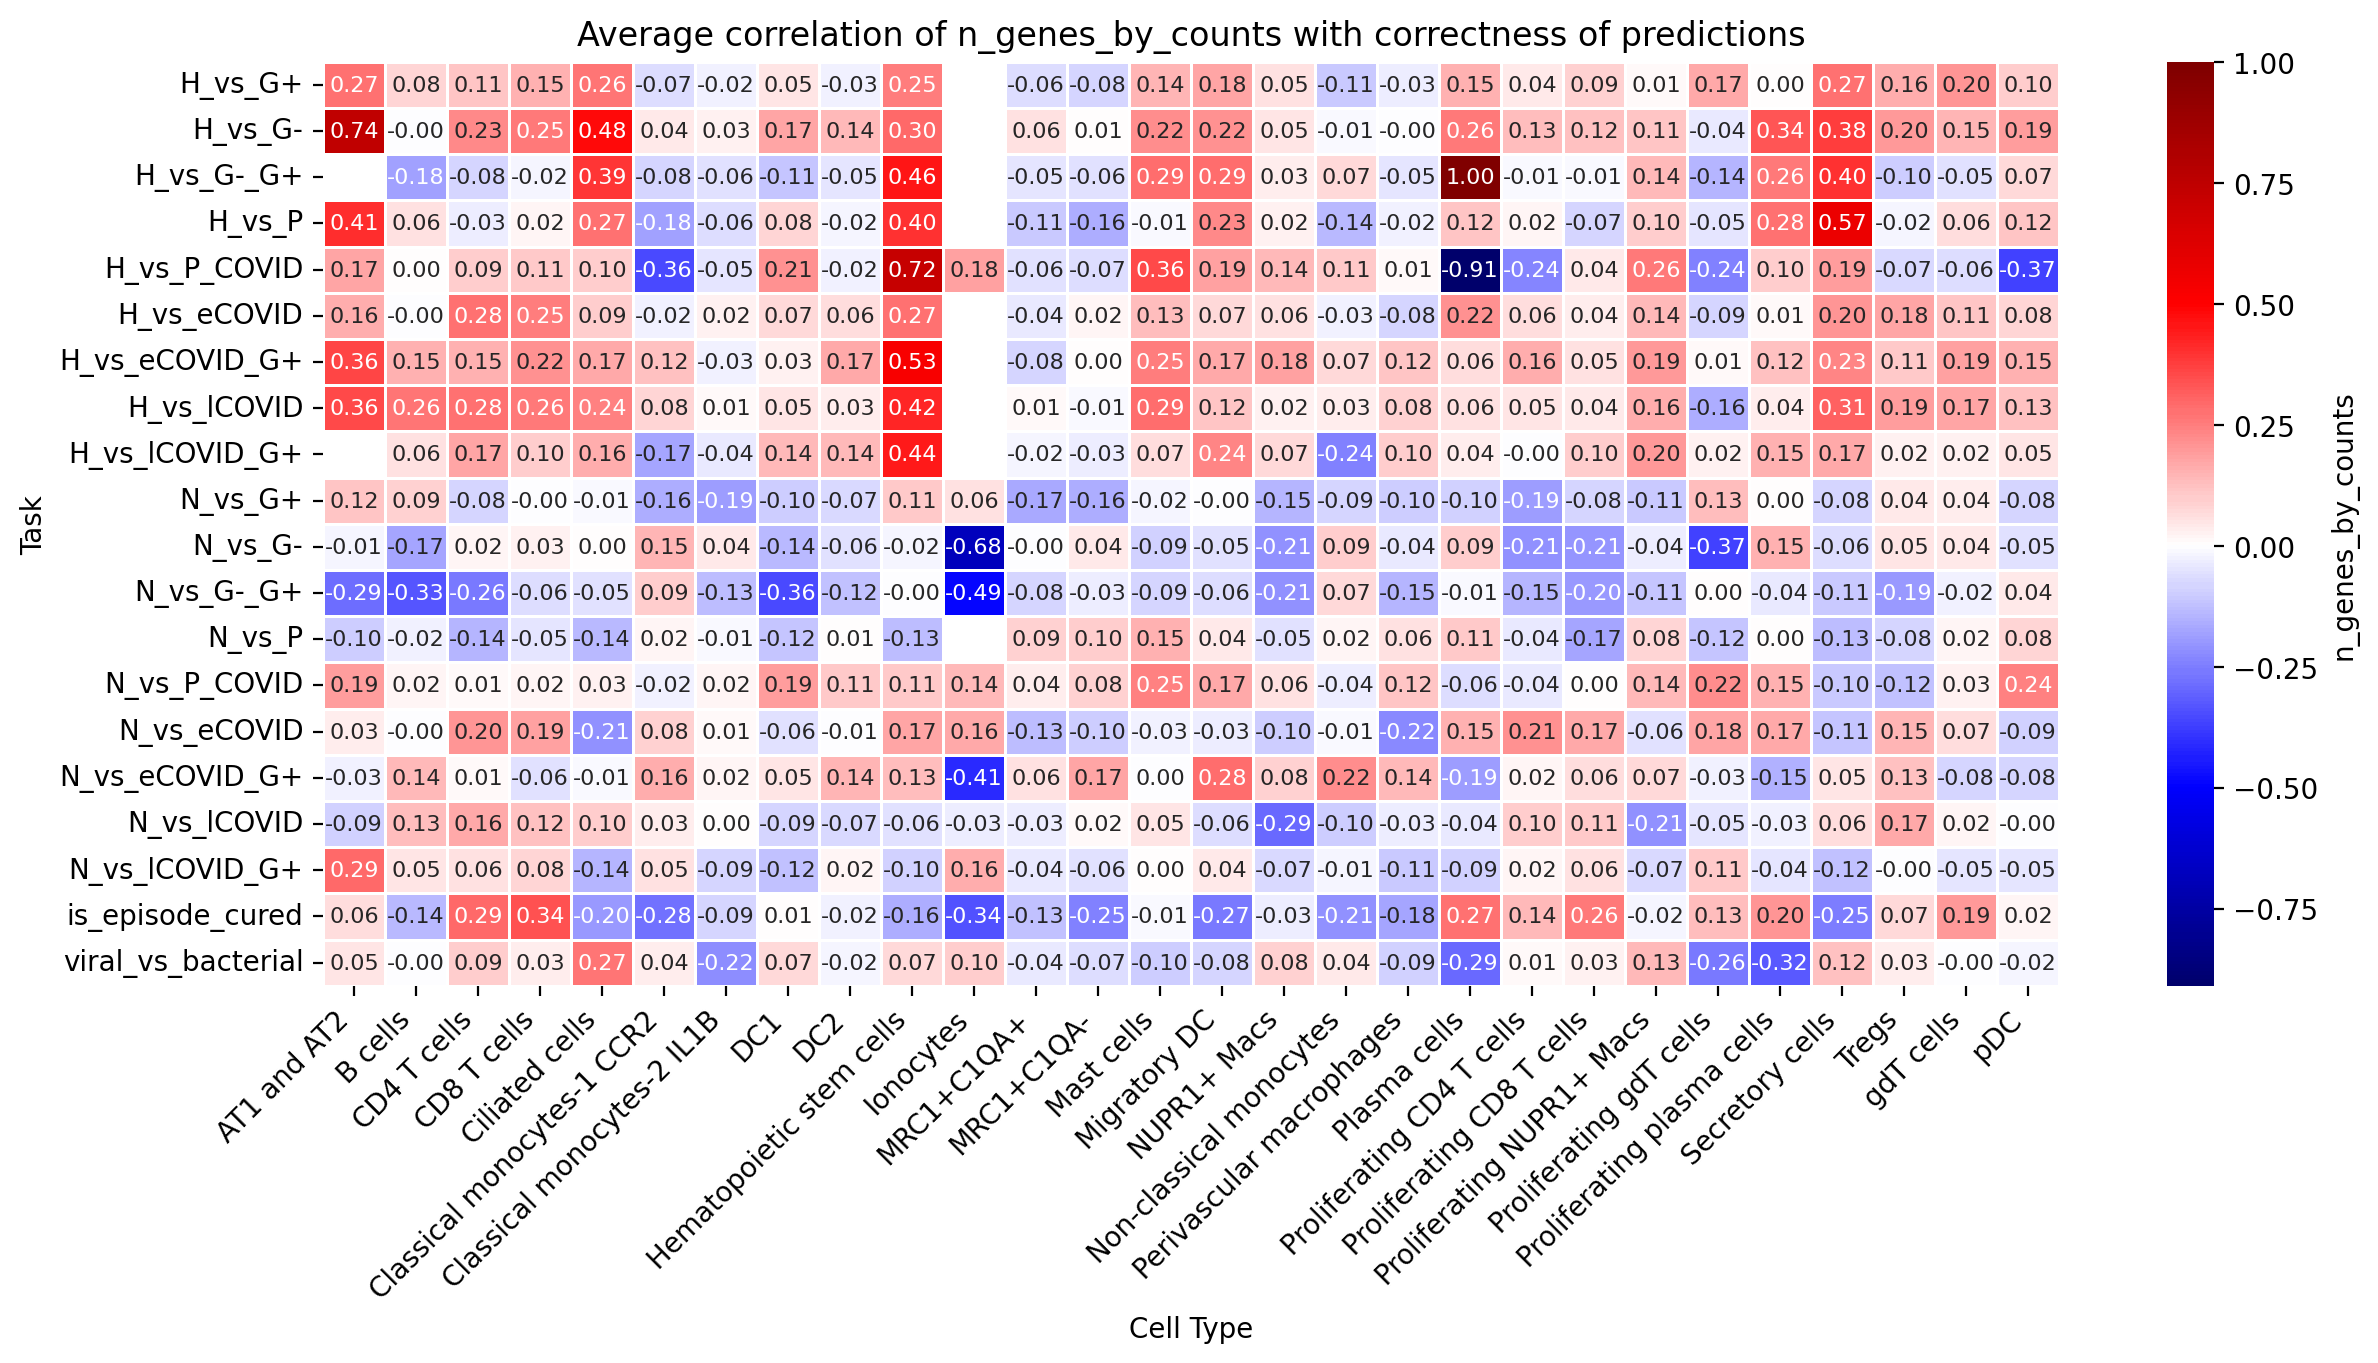

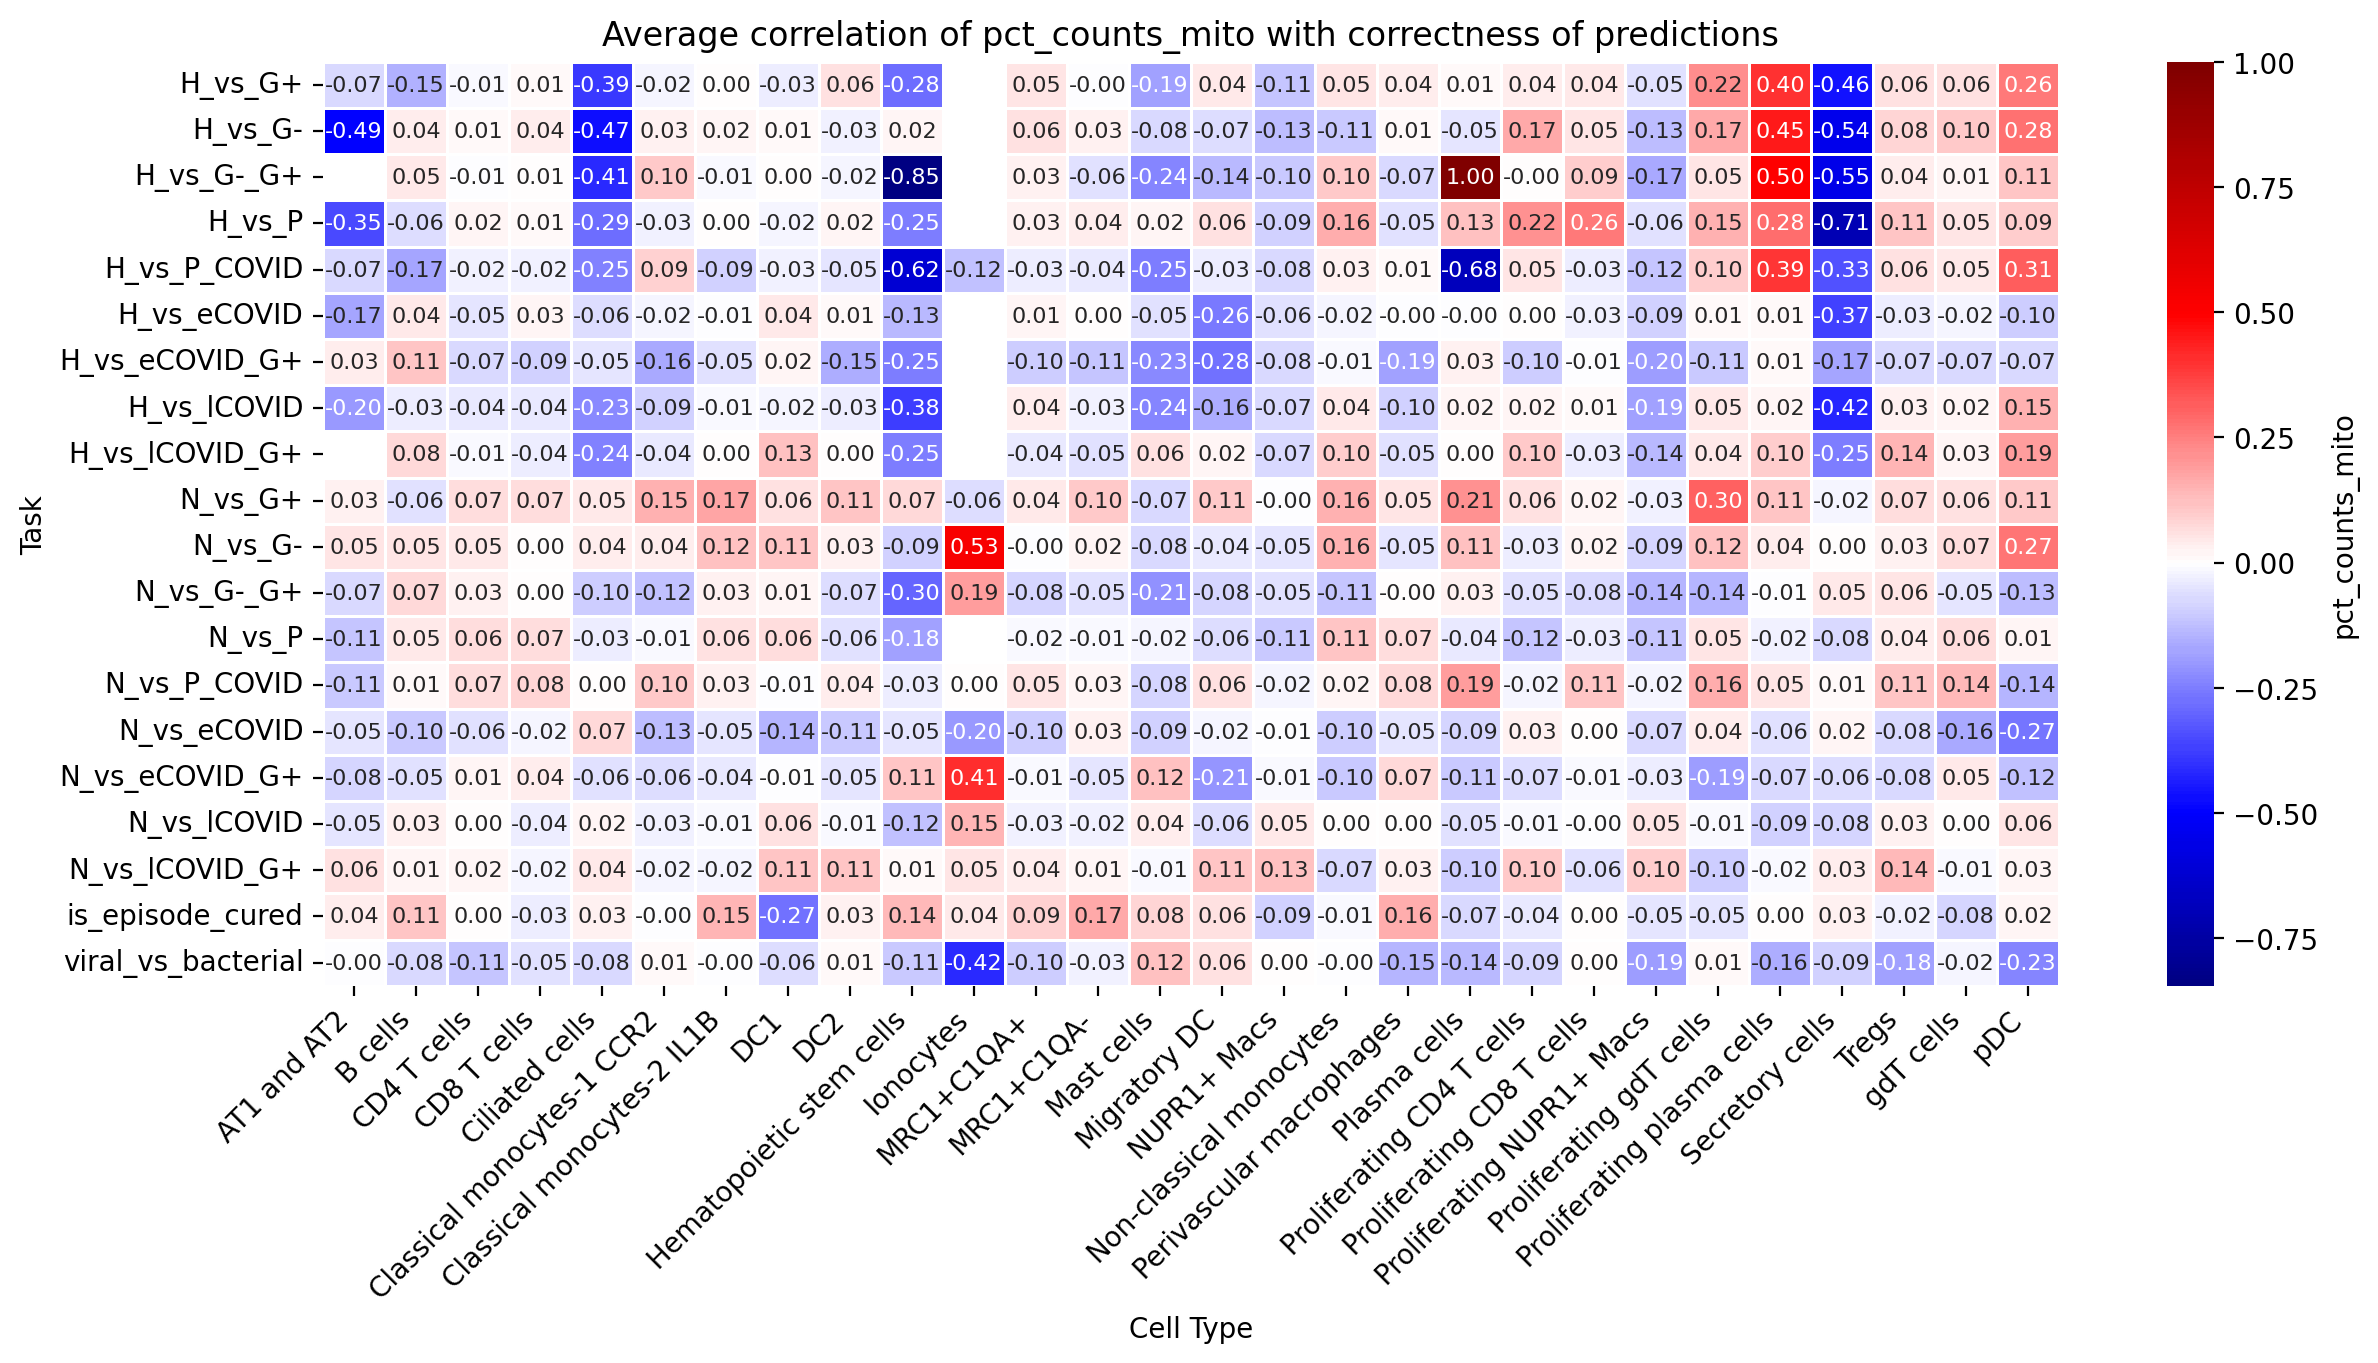

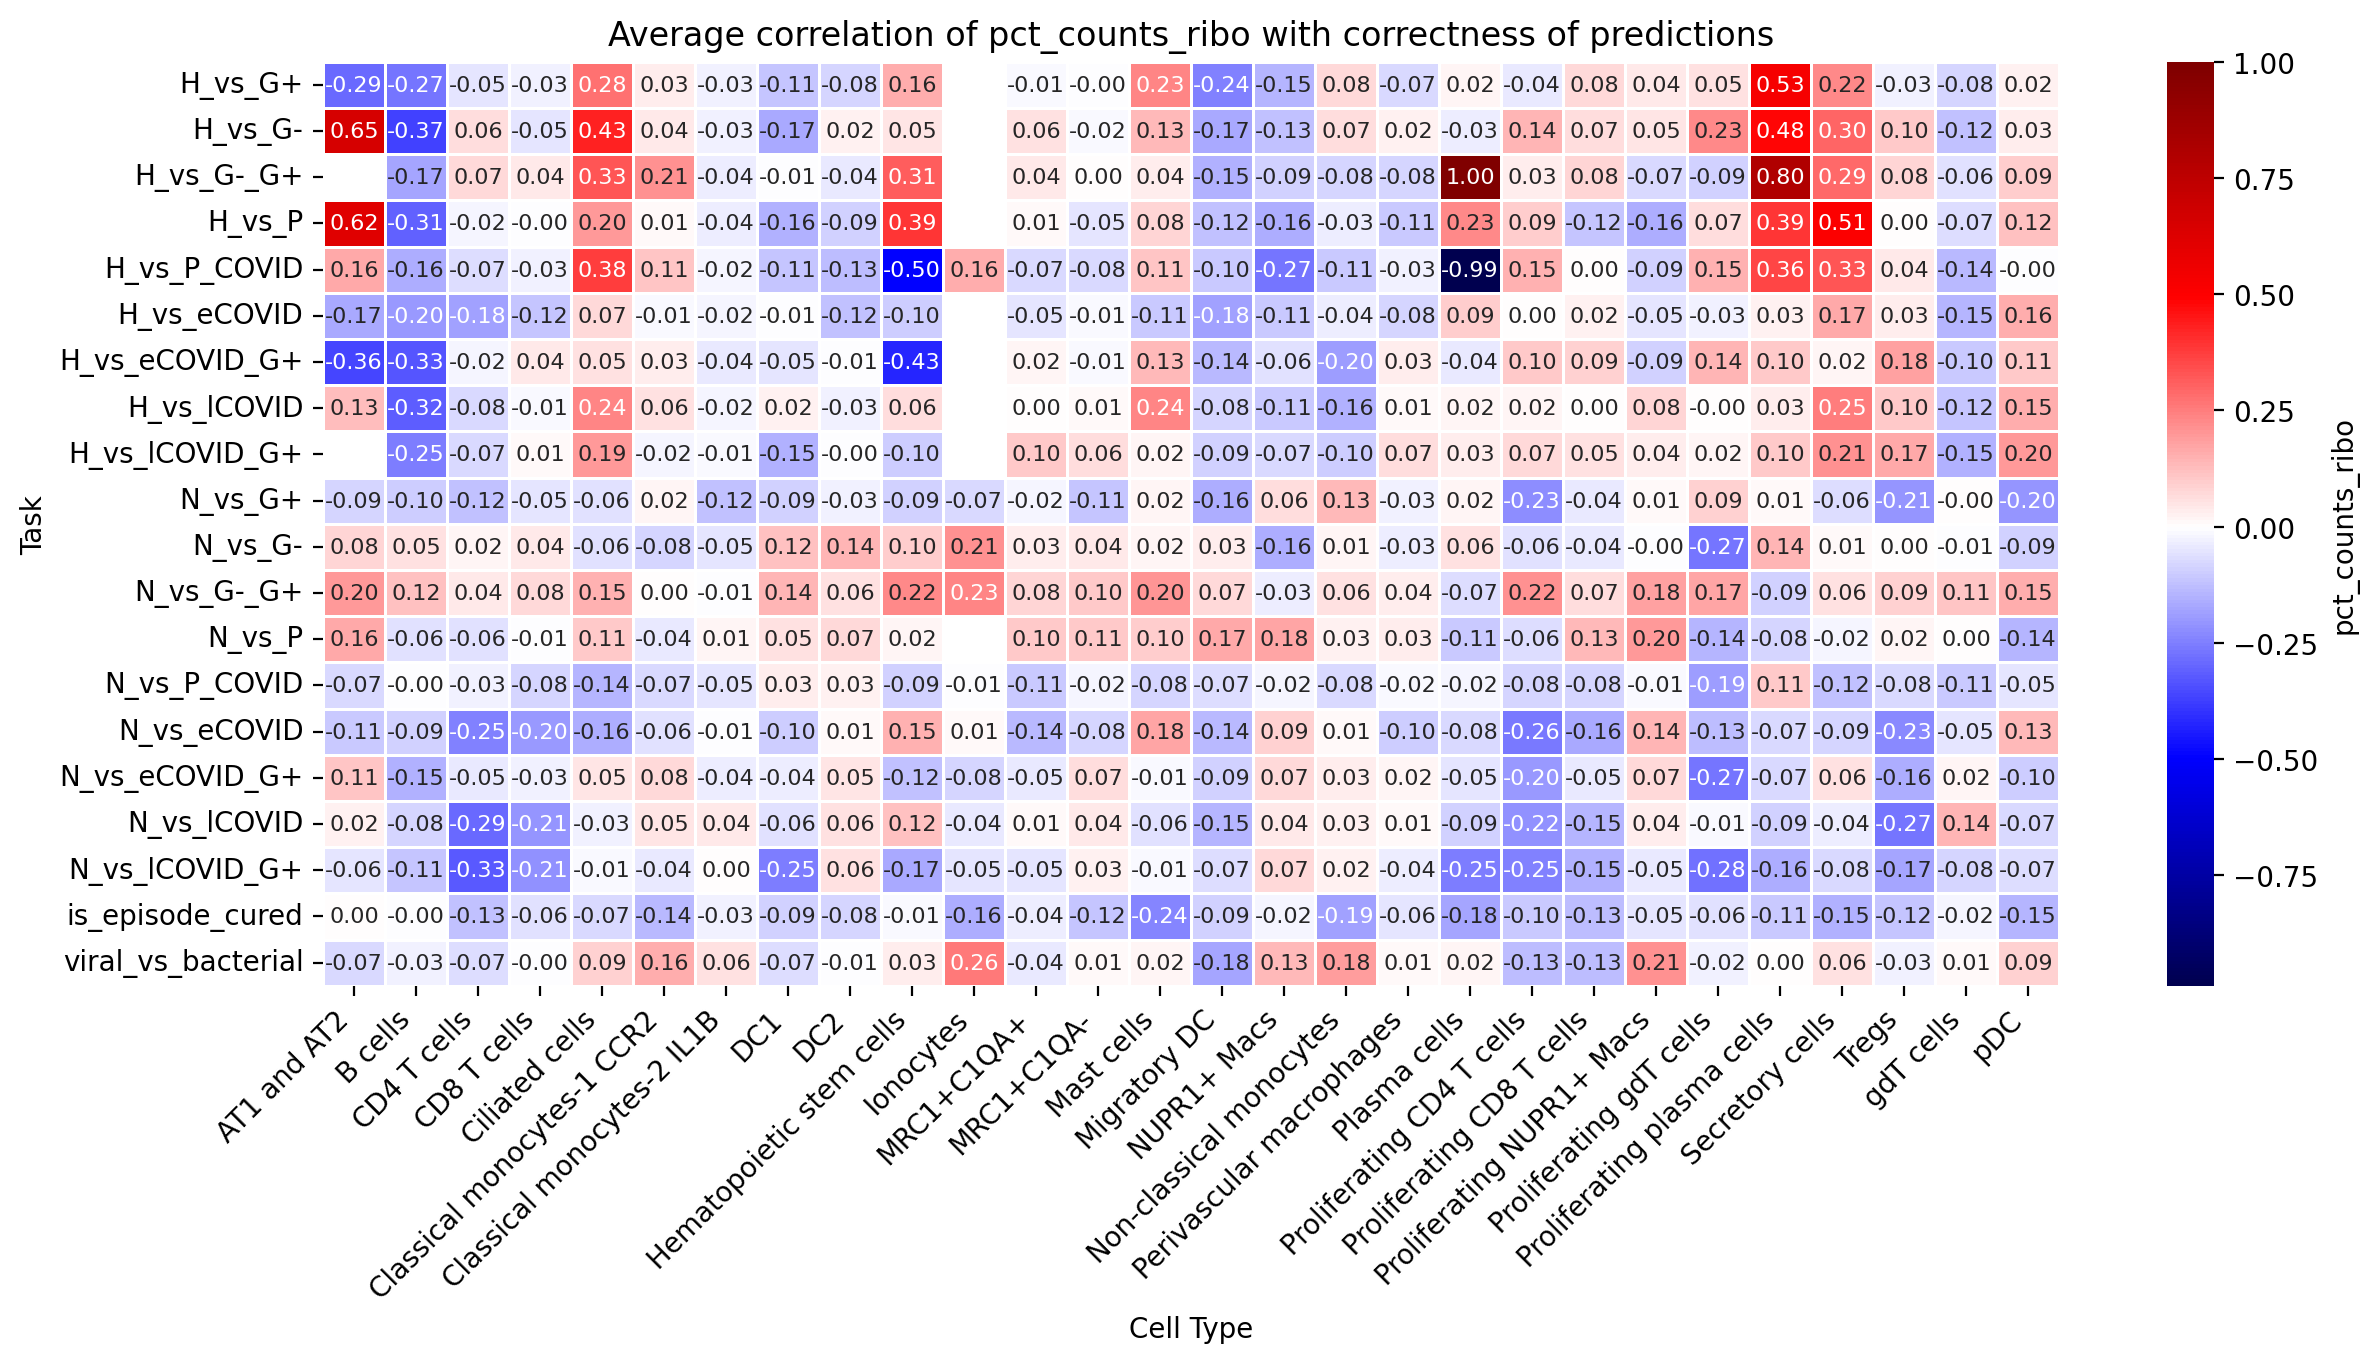

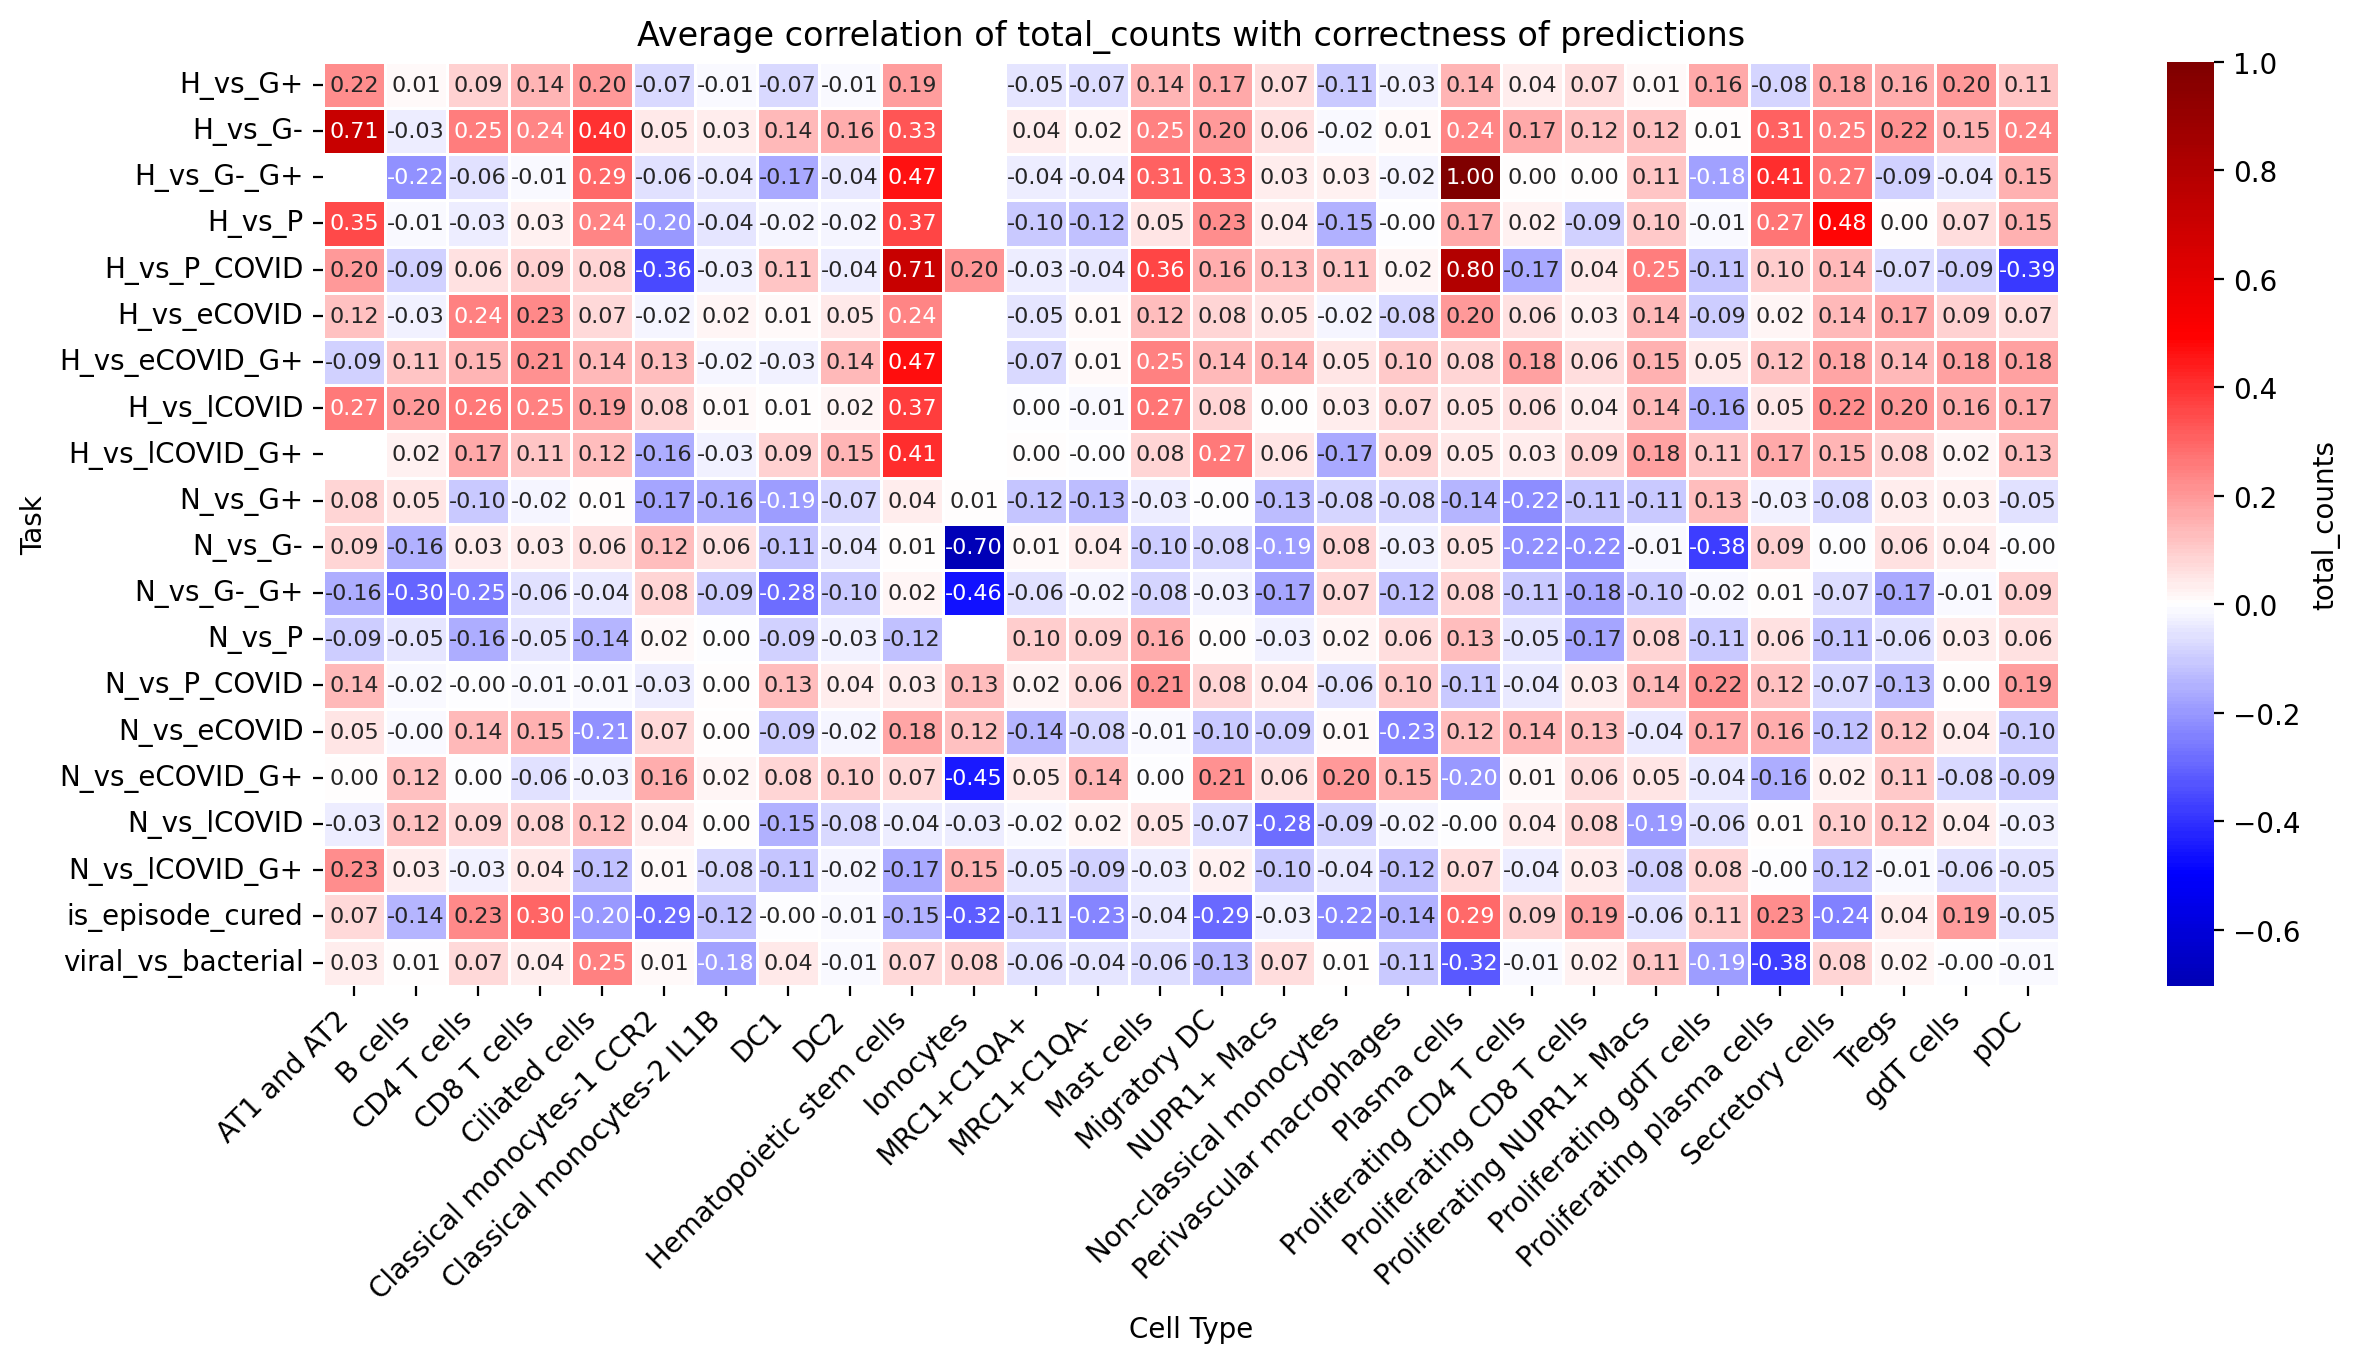

In [60]:
# List of numeric columns to create heatmaps for
numeric_columns = corr_results_agg.covariate.unique()

# Create a heatmap for each numeric column
for column in numeric_columns:
    # Pivot the dataframe to create a 2D matrix
    pivot_data = corr_results_agg.loc[corr_results_agg.covariate.eq(column)].pivot(index='task', columns='cell_type', values='corr_coef')

    # Create a mask for NaN values
    mask = pivot_data.isnull()

    # Create a new figure
    fig, ax = plt.subplots(figsize=(14, 6))

    # Generate the heatmap
    sns.heatmap(
        pivot_data,
        annot=True,
        cmap='seismic',
        fmt='.2f',
        annot_kws={
            'size': 8
        },
        cbar_kws={'label': column},
        mask=mask,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        center=0
    )

    # Set the title and labels
    ax.set_title(f'Average correlation of {column} with correctness of predictions')
    ax.set_xlabel('Cell Type')
    ax.set_ylabel('Task')

    # Rotate x-axis labels for better readability if needed
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.show()